# The whole loop on real Polymarket books

Recipe 05/07 runs the pipeline on a synthetic panel, which proves the plumbing
and nothing about the world. This one runs it on real tick-level Polymarket
data: real markets, real order books, real UMA-verified resolutions. The
question it answers is the one that matters and the one a synthetic panel
cannot: do any of the standard rules survive real costs?

The answer here is no, every one of them loses, and the loss tracks the number
of round trips. That is the useful outcome. A tutorial that showed a winning
strategy on one day of six markets would be teaching you to fool yourself, so
this one spends its length on how you establish that a rule does *not* work,
which is the same machinery you need to believe one that does.

## Terms used here

| term            | meaning |
| --------------- | --- |
| tick-level data | every recorded book event, rather than a periodic sample |
| round trip      | one buy and the sell that closes it, which is where costs are paid |
| cost budget     | the total costs a strategy must clear before it makes anything |
| maker / taker   | a maker posts and waits; a taker crosses the spread and trades immediately |
| UMA             | the decentralized oracle protocol Polymarket resolves its markets through |
| holdout         | data deliberately untouched until the end, which can only be spent once |
| deflated Sharpe | a Sharpe adjusted downward for how many variants were tried |
| negative result | establishing that a rule does not work, using the same machinery as believing one that does |

New to any of these? [GLOSSARY.md](../../GLOSSARY.md) defines them at more
length, along with every other term the cookbook uses.

In [1]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.compute as pc
import pyarrow.parquet as pq

import cookbook_utils as cu
import h5i_db
from h5i_db import backtest, quant, venues

CACHE = Path("data/cache/kaggle-polymarket")
FEE_RATE = 0.07
QUANTITY = 50.0

## The data, and what it is not

A bounded, non-commercial sample of tick-level Polymarket order books. It is
not redistributed here: the cell below prints the download commands if the
files are absent, the way recipes 04/04 and 04/05 do.

Three limits shape everything below, and all three are properties of the
capture rather than of h5i-db.

In [2]:
missing = cu.kaggle_missing_files(CACHE)
if missing:
    print("This recipe needs the Kaggle sample. Missing:", missing)
    print(f"\nDataset: {cu.KAGGLE_POLYMARKET_DATASET}  (licence {cu.KAGGLE_POLYMARKET_LICENSE})")
    for line in cu.kaggle_download_commands(CACHE):
        print("  " + line)
    raise SystemExit("download the sample, then re-run")

snapshots = CACHE / "snapshots_2026-03-09.parquet"
targets_path = CACHE / "market_targets.parquet"
print(f"snapshots  {pq.ParquetFile(snapshots).metadata.num_rows:,} rows")
print(f"targets    {pq.ParquetFile(targets_path).metadata.num_rows:,} markets")
print(f"licence    {cu.KAGGLE_POLYMARKET_LICENSE} (non-commercial)")

snapshots  734,504 rows
targets    123,895 markets
licence    CC BY-NC 4.0 (non-commercial)


**One day.** The book capture covers a single date, and the markets it covers
mostly resolve later, so almost nothing can be held to resolution. The study is
intraday and `realized_pnl` is the number, not `settlement_pnl`. How many
markets actually resolve inside the window is computed below rather than
assumed, because "mostly" is not a basis for an accounting choice.

**YES side only.** The capture carries the YES token's book and not the NO
token's. So the pair-parity trade from recipe 05/01 is not testable here, and
any rule must trade the YES book. This is checked below rather than assumed.

**Full depth.** Snapshots carry 150 to 180 levels per side. A rule that takes
the touch reads two of them, so this recipe truncates to top-of-book and the
importer reports exactly how many levels that dropped.

In [3]:
raw = pq.ParquetFile(snapshots)
sample = next(raw.iter_batches(batch_size=1, columns=["market_id", "update_type", "data"]))
event = json.loads(sample.to_pylist()[0]["data"])
print("one raw snapshot event carries:", sorted(event))
print(f"  side       {event['side']}")
print(f"  token_id   {str(event['token_id'])[:24]}...")
print(f"  bids/asks  {len(event['bids'])} / {len(event['asks'])} levels")
print(f"  first bid  {event['bids'][0]} (price, size as strings)")

one raw snapshot event carries: ['asks', 'best_ask', 'best_bid', 'bids', 'market_id', 'side', 'timestamp', 'token_id', 'update_type']
  side       YES
  token_id   445546811080747933138936...
  bids/asks  8 / 59 levels
  first bid  ['0.001', '11680'] (price, size as strings)


## Pick real, resolved markets

`market_targets.parquet` carries one row per market with the UMA-verified
outcome. `target` is documented as `1 = YES wins`; taking that from the
dataset's own README rather than inferring it from prices is the difference
between a label and a guess.

| column | type | meaning |
|---|---|---|
| `condition_id` | `string` | the market, and the join key to the book capture |
| `question` | `string` | what was actually being traded |
| `end_date` | `string` | ISO-8601; when the market closes |
| `closed` | `bool` | whether trading has stopped |
| `clob_token_id_yes` / `_no` | `string` | the per-outcome tokens |
| `target` | `int8` | 1 = YES wins, 0 = NO wins, null = unresolved |

In [4]:
ids = pq.read_table(snapshots, columns=["market_id"]).column("market_id").combine_chunks()
coverage = pd.DataFrame(pc.value_counts(ids).to_pylist()).rename(
    columns={"values": "condition_id", "counts": "snapshot_rows"}
)
targets = pq.read_table(targets_path).to_pandas()
pool = coverage.merge(targets, on="condition_id").query("target.notna()")
print(f"markets in the capture:        {len(coverage):,}")
print(f"also defined in the labels:    {len(coverage.merge(targets, on='condition_id')):,}")
print(f"and resolved:                  {len(pool):,}")

chosen = pool.sort_values("snapshot_rows", ascending=False).head(6).reset_index(drop=True)
print()
print(chosen[["question", "snapshot_rows", "end_date", "target"]].to_string(index=False))

markets in the capture:        22,715
also defined in the labels:    12,733
and resolved:                  1,826

                                                                                        question  snapshot_rows             end_date  target
                                               Will Iran close the Strait of Hormuz by March 31?           2718 2026-12-31T00:00:00Z     1.0
                     Will there be no change in Fed interest rates after the March 2026 meeting?           1586 2026-03-18T00:00:00Z     1.0
                               Will Michael B. Jordan win Best Actor at the 98th Academy Awards?           1346 2026-03-15T00:00:00Z     1.0
                   Will the Fed decrease interest rates by 50+ bps after the March 2026 meeting?           1344 2026-03-18T00:00:00Z     0.0
Will The Greens win the second most seats in the 2026 Baden-Württemberg parliamentary elections?           1314 2026-03-08T00:00:00Z     0.0
                   Will the Fed increase

## Market definitions from the real labels

`MarketSpec` pairs `outcome_labels` with `tokens` positionally, so the YES
token must sit at the same index as the `YES` label. Getting that backwards
would attribute every fill to the wrong side, which is why the spec refuses
the ways of expressing it ambiguously.

In [5]:
specs = [
    venues.MarketSpec(
        instrument_id=row.condition_id,
        venue="polymarket",
        outcome_labels=("YES", "NO"),
        tokens=(row.clob_token_id_yes, row.clob_token_id_no),
        tick_size=0.001,
        lot_size=1.0,
        expiration_ns=int(pd.Timestamp(row.end_date).value),
        settlement_observable_ns=int(pd.Timestamp(row.end_date).value),
        winner_outcome=0 if int(row.target) == 1 else 1,
        metadata={"question": row.question},
    )
    for row in chosen.itertuples()
]
db = h5i_db.Database(cu.fresh_db("05_real_polymarket_end_to_end"), create=True)
markets = venues.write_markets(db, specs, note="UMA-verified labels")
print(f"instruments {markets.tables['instruments'].rows} rows "
      f"({len(specs)} markets x 2 outcomes)")
print(f"resolutions {markets.tables['resolutions'].rows} rows")
for spec in specs[:3]:
    print(f"  {spec.outcome_labels[spec.winner_outcome]:3} won: {spec.metadata['question'][:64]}")

instruments 12 rows (6 markets x 2 outcomes)
resolutions 6 rows
  YES won: Will Iran close the Strait of Hormuz by March 31?
  YES won: Will there be no change in Fed interest rates after the March 20
  YES won: Will Michael B. Jordan win Best Actor at the 98th Academy Awards


## Ingest the real books

The capture is a websocket recording written straight to Parquet: the event is
a JSON string in one column, and the token lives inside it. That is a third
level shape beside nested lists and flat rows, so it is another
`ArchiveLayout` literal rather than another code path.

`max_levels=1` keeps top of book. The truncation is opt-in and reported,
because a silently shallower book is a different book.

In [6]:
layout = venues.ArchiveLayout(
    name="kaggle-polymarket-top",
    timestamp_column="timestamp_received",
    timestamp_unit="ms",
    instrument_column="market_id",
    event_type_column="update_type",
    snapshot_events=("book_snapshot",),
    levels=venues.LevelLayout(style="payload"),
    payload_column="data",
    payload_token_field="token_id",
    payload_outcome_field="side",
    outcome_labels=("YES", "NO"),
    max_levels=1,
)
started = time.time()
ingest = venues.ingest_archive(
    db, files=[snapshots], markets=specs, layout=layout, note="tick capture, top of book"
)
print(f"ingested in {time.time() - started:.1f}s")
print(ingest)
for item in ingest.skipped:
    print(" ", json.dumps(item))
db.snapshot("real-v1", tables=["instruments", "book_deltas", "resolutions"],
            note="real Polymarket books, top of book")

ingested in 4.1s
IngestReport(vendor='kaggle-polymarket-top', book_deltas=19174, coverage=n/a, gaps=0, replayed=False)
  {"reason": "depth_truncated", "max_levels": 1, "levels_dropped": 1298277}


{'name': 'real-v1',
 'created_at_ns': 1785438088028103534,
 'note': 'real Polymarket books, top of book',
 'entries': {'261bad44-cdf7-462a-ad8b-a109b954726d': {'table_name': 'instruments',
   'sequence': 1,
   'manifest_checksum': '118d8642b5601227f794cc7b42f55732a360d3bcef469a3289e7ba4e6564ab28'},
  'be2b5510-244c-4592-a79e-ca7a9b8fbc26': {'table_name': 'book_deltas',
   'sequence': 1,
   'manifest_checksum': 'abca98d17d771f49a48d558b0e1a90204315f3a40c54b619c7a444e1f8301ca0'},
  'e78e3465-2623-452f-ad71-a1a9ece4d0e9': {'table_name': 'resolutions',
   'sequence': 1,
   'manifest_checksum': '26475538f20419c949ab65b66cfd022a7367661e510b4aa5196df9c55b12b453'}},
 'checksum': '385853033df0f6444cd274bb209eac01a043276c8bb1565cd2f86e8174c15a31'}

The YES-only claim, checked rather than asserted. Only outcome 0 has a book, so
the NO side of these markets is untradeable in this study.

In [7]:
sides = db.sql(
    """
    SELECT outcome, count(DISTINCT event_index) AS events,
           count(DISTINCT instrument_id) AS markets,
           min(price) AS low, max(price) AS high
    FROM book_deltas GROUP BY outcome ORDER BY outcome
    """
).to_pandas()
print(sides.to_string(index=False))
malformed = db.sql(
    """
    SELECT count(*) AS malformed FROM (
        SELECT event_index FROM book_deltas GROUP BY event_index
        HAVING count(DISTINCT outcome) > 1
            OR sum(CASE WHEN is_last THEN 1 ELSE 0 END) <> 1)
    """
).to_pandas()
print(f"\nmalformed book events: {int(malformed.malformed.iloc[0])}")

 outcome  events  markets   low  high
       0    9588        6 0.001  0.99

malformed book events: 0


## The panel these books make

Real spreads, and they are not uniform: a market trading at 0.002 and one
trading at 0.47 are different instruments for execution purposes even though
both are one contract.

In [8]:
panel = backtest.quote_panel(db, snapshot="real-v1")
panel["spread"] = panel.ask - panel.bid
panel["mid"] = (panel.bid + panel.ask) / 2
print(f"{len(panel):,} quote rows across {panel.instrument_id.nunique()} markets")
print(panel[["bid", "ask", "spread", "mid"]].describe().round(4).to_string())
print("\nhalf-spread as a share of the mid, by price level:")
levels = panel.assign(level=lambda f: f.mid.round(1)).groupby("level").agg(
    quotes=("mid", "size"),
    half_spread=("spread", lambda s: s.mean() / 2),
)
levels["half_spread_pct_of_mid"] = levels.half_spread / levels.index * 100
print(levels.round(4).to_string())

9,576 quote rows across 6 markets
             bid        ask     spread        mid
count  9574.0000  9576.0000  9574.0000  9574.0000
mean      0.5163     0.5211     0.0049     0.5187
std       0.4462     0.4438     0.0164     0.4449
min       0.0010     0.0020     0.0010     0.0025
25%       0.0030     0.0040     0.0010     0.0035
50%       0.4720     0.4740     0.0010     0.4730
75%       0.9800     0.9820     0.0030     0.9810
max       0.9880     0.9900     0.4710     0.9890

half-spread as a share of the mid, by price level:
       quotes  half_spread  half_spread_pct_of_mid
level                                             
0.0      3467       0.0015                     inf
0.1       239       0.0207                 20.7092
0.2       147       0.0354                 17.7007
0.3        77       0.0199                  6.6255
0.5      1138       0.0014                  0.2869
0.6       204       0.0036                  0.6054
0.7         4       0.0266                  3.8036
1.0  

## Run the whole pack

Eleven rules, one pin, one fee model, nothing else varying. Ranking on
`realized_pnl` because nothing settles here: every position that survives the
day is unresolved, so closed round trips are the only honest scoreboard.

In [9]:
started = time.time()
results = {}
rows = []
for name, generator in sorted(backtest.STRATEGIES.items()):
    plan = generator(panel)
    if not plan.num_signals:
        rows.append({"strategy": name, "signals": 0, "fills": 0, "realized_pnl": None})
        continue
    table = f"signals_{name}"
    db.create_table(table, plan.signals.schema, time_column="ts")
    db.append(table, plan.signals)
    result = backtest.execute(
        db,
        backtest.BacktestConfig(
            run_id=f"pack-{name}",
            data=backtest.DataConfig(signals=table, snapshot="real-v1"),
            portfolio=backtest.PortfolioConfig(starting_cash=100_000.0),
            execution=backtest.ExecutionConfig(fee_kind="kalshi", fee_rate=FEE_RATE),
            output=backtest.OutputConfig(equity_interval_nanos=60 * 1_000_000_000),
            metadata=plan.to_metadata(),
        ),
    )
    results[name] = result
    summary = result.summary()
    rows.append(
        {
            "strategy": name,
            "signals": plan.num_signals,
            "fills": summary["fills"],
            "realized_pnl": summary["realized_pnl"],
            "fees": summary["commissions"],
        }
    )
board = pd.DataFrame(rows).sort_values("realized_pnl", ascending=False, na_position="last")
print(f"{len(results)} runs in {time.time() - started:.1f}s\n")
print(board.to_string(index=False))

11 runs in 2.7s

             strategy  signals  fills  realized_pnl     fees
   late_favorite_hold        2      2     -0.040000  0.04000
           deep_value        3      3     -0.060000  0.06000
           panic_fade       10     10     -5.760000  0.56000
       vwap_reversion       34     34     -7.178339  2.51875
final_period_momentum      190    190    -14.905160  8.80606
             breakout      139    139    -23.413468  8.02366
        ema_crossover      284    284    -31.780574 15.45775
       mean_reversion      342    342    -33.278978 21.38339
   threshold_momentum       70     70    -38.197599  6.95526
        rsi_reversion      741    741    -83.735248 48.16819
 microprice_imbalance     1188   1187   -136.432907 82.32064


Every rule loses, and the ordering is close to monotone in trade count. That is
the shape of a cost problem rather than eleven separate bad ideas: each round
trip pays the spread and the fee, and the rules that trade most pay most.

In [10]:
traded = board.dropna(subset=["realized_pnl"])
traded = traded[traded.fills > 0].assign(
    pnl_per_fill=lambda f: f.realized_pnl / f.fills,
    fee_per_fill=lambda f: f.fees / f.fills,
)
print(traded[["strategy", "fills", "pnl_per_fill", "fee_per_fill"]].round(4).to_string(index=False))
correlation = traded.fills.corr(traded.realized_pnl)
print(f"\ncorrelation between trade count and P&L: {correlation:+.3f}")

             strategy  fills  pnl_per_fill  fee_per_fill
   late_favorite_hold      2       -0.0200        0.0200
           deep_value      3       -0.0200        0.0200
           panic_fade     10       -0.5760        0.0560
       vwap_reversion     34       -0.2111        0.0741
final_period_momentum    190       -0.0784        0.0463
             breakout    139       -0.1684        0.0577
        ema_crossover    284       -0.1119        0.0544
       mean_reversion    342       -0.0973        0.0625
   threshold_momentum     70       -0.5457        0.0994
        rsi_reversion    741       -0.1130        0.0650
 microprice_imbalance   1187       -0.1149        0.0694

correlation between trade count and P&L: -0.972


## Where the money went

The decomposition, from the fills the engine actually produced. A taker pays
half the spread on entry and half on exit, plus the venue fee on both legs.
Comparing that budget with the realized loss says whether a rule was unlucky or
merely expensive.

In [11]:
worst = board.dropna(subset=["realized_pnl"]).iloc[-1].strategy
fills = results[worst].fills.to_pandas()
# A fill is stamped at the event that matched it, which need not be a quote
# instant, so this is an as-of join backwards onto the book it met.
paired = pd.merge_asof(
    fills.sort_values("ts"),
    panel[["instrument_id", "ts", "bid", "ask", "mid"]].sort_values("ts"),
    on="ts",
    by="instrument_id",
    direction="backward",
)
matched = paired.dropna(subset=["bid", "ask"])
print(f"fills matched to a quote: {len(matched)} of {len(paired)}")
paired["half_spread_cost"] = (paired.ask - paired.bid).abs() / 2 * paired.quantity
budget = pd.DataFrame(
    [
        {"component": "fees paid", "cost": float(fills.commission.sum())},
        {"component": "half spread crossed", "cost": float(paired.half_spread_cost.sum())},
    ]
)
budget.loc[len(budget)] = {"component": "total cost", "cost": budget.cost.sum()}
budget.loc[len(budget)] = {
    "component": "realized P&L",
    "cost": float(results[worst].summary()["realized_pnl"]),
}
gross = float(budget.loc[budget.component == "total cost", "cost"].iloc[0]) + float(
    results[worst].summary()["realized_pnl"]
)
budget.loc[len(budget)] = {"component": "implied gross edge", "cost": gross}
print(f"{worst}, {len(fills)} fills:")
print(budget.round(2).to_string(index=False))

fills matched to a quote: 1187 of 1187
microprice_imbalance, 1187 fills:
          component    cost
          fees paid   82.32
half spread crossed   58.52
         total cost  140.84
       realized P&L -136.43
 implied gross edge    4.41


Read the last line. Cost and loss agree to within a few percent, so the implied
gross edge is approximately zero: the rule was not beaten by costs on top of a
real signal, it had no signal and paid the costs. That is a different diagnosis
from "promising but too expensive", and it is the one the arithmetic supports.
A rule with genuine gross edge would show a gross number clearly above zero and
a loss smaller than its cost budget.

## Take the least-bad rule through the honest machinery

Ranking eleven rules and running the best one again is a search, and the search
inflates whatever it picks. Walk-forward with a shortlist holdout, then a
deflated Sharpe against the number of things tried, is what turns "this one was
least bad" into a defensible statement.

In [12]:
# "Least bad" is meaningless when it is won by a rule that barely trades:
# `late_favorite_hold` fires twice, so of course it loses least, and a
# walk-forward over it would score empty windows. Rank among rules that traded
# enough for a fold to contain trades, and say what the cut was.
MIN_FILLS = 30
eligible = board.dropna(subset=["realized_pnl"]).query("fills >= @MIN_FILLS")
excluded = board.dropna(subset=["realized_pnl"]).query("fills < @MIN_FILLS")
best_name = eligible.iloc[0].strategy
print(f"rules with at least {MIN_FILLS} fills: {len(eligible)}")
print(f"excluded as too quiet to score: {list(excluded.strategy)}")
print(f"best among the rest: {best_name} "
      f"({int(eligible.iloc[0].fills)} fills, {eligible.iloc[0].realized_pnl:+.2f})")
stamps = list(
    db.sql("SELECT DISTINCT ts_init FROM book_deltas ORDER BY ts_init").to_pandas().ts_init
)
cuts = [0, len(stamps) // 3, len(stamps) // 2, 2 * len(stamps) // 3, len(stamps) - 1]
walk = backtest.WalkForward.of(
    backtest.ValidationWindows(train=(stamps[cuts[0]], stamps[cuts[1]]),
                               holdout=(stamps[cuts[1]], stamps[cuts[2]])),
    backtest.ValidationWindows(train=(stamps[cuts[2]], stamps[cuts[3]]),
                               holdout=(stamps[cuts[3]], stamps[cuts[4]])),
)
study = backtest.study(
    db,
    study_id="real-fees",
    base=backtest.BacktestConfig(
        run_id="real-fees",
        data=backtest.DataConfig(signals=f"signals_{best_name}", snapshot="real-v1"),
        portfolio=backtest.PortfolioConfig(starting_cash=100_000.0),
        execution=backtest.ExecutionConfig(fee_kind="kalshi", fee_rate=FEE_RATE),
        output=backtest.OutputConfig(equity_interval_nanos=60 * 1_000_000_000),
    ),
    parameters={"execution.fee_rate": [0.0, 0.02, FEE_RATE]},
    validation=walk,
    selection=backtest.TopK(k=2, metric="realized_pnl"),
)
columns = ["trial", "parameters", "train_median_realized_pnl", "holdout_median_realized_pnl"]
print(pd.DataFrame(study.ranked())[columns].to_string(index=False))
print(f"\ntrials {len(study.trials)}, reached the holdout {len(study.selected)}")

rules with at least 30 fills: 8
excluded as too quiet to score: ['late_favorite_hold', 'deep_value', 'panic_fade']
best among the rest: vwap_reversion (34 fills, -7.18)


 trial                   parameters  train_median_realized_pnl  holdout_median_realized_pnl
     0  {"execution.fee_rate": 0.0}                  -2.108839                       -0.455
     1 {"execution.fee_rate": 0.02}                  -2.458839                       -0.510

trials 3, reached the holdout 2


Even at a zero fee the rule does not make money, which localises the problem:
it is the spread, not the venue's fee schedule. That distinction matters,
because a fee is negotiable at volume and a spread is not.

In [13]:
zero_fee = [
    row for row in study.trials
    if json.loads(row["parameters"])["execution.fee_rate"] == 0.0
]
if zero_fee:
    row = zero_fee[0]
    print(f"at fee 0.00: train median {row['train_median_realized_pnl']:+.2f}, "
          f"holdout median {row.get('holdout_median_realized_pnl', float('nan')):+.2f}")

at fee 0.00: train median -2.11, holdout median -0.46


In [14]:
equity = results[best_name].equity.to_pandas().sort_values("ts")
levels_ = equity.equity.tolist()
returns = [
    (levels_[i] - levels_[i - 1]) / levels_[i - 1]
    for i in range(1, len(levels_))
    if levels_[i - 1]
]
deflated = quant.deflated_sharpe(returns, trials=len(backtest.STRATEGIES))
print(f"observed Sharpe                 {deflated.sharpe:+.3f}")
print(f"benchmark after {deflated.trials} rules tried  {deflated.benchmark:+.3f}")
print(f"P(true Sharpe > benchmark)      {deflated.probability:.3f}")
print(f"\nthe search tried {len(backtest.STRATEGIES)} rules, so the bar the winner had")
print("to clear was raised accordingly, and it did not clear it")

observed Sharpe                 -0.062
benchmark after 11 rules tried  +0.047
P(true Sharpe > benchmark)      0.000

the search tried 11 rules, so the bar the winner had
to clear was raised accordingly, and it did not clear it


## Settlement does not apply here, and the engine says so

Settlement is per position and gated on one question: did the replay reach the
instant that market's result became knowable? Only one of these six resolves
inside the capture, so a position held anywhere else cannot be settled, and the
engine names each one it refused rather than marking it to the eventual winner.
Which runs hit that is a fact about where each rule was still long at the close,
so it is tabulated rather than asserted.

Read the `refused` column, not the flag. `settlement_applied` is true when
settlement reached *any* position, so a run showing `True` alongside four
refusals is normal on a mixed panel and is not a contradiction. The
authoritative per-position signal is whether `bt_positions.settlement_pnl` is
null. A panel whose markets all resolve at one instant hides the distinction,
which is why recipe 05/05 could treat the flag as all-or-nothing and this one
cannot.

In [15]:
capture_end = int(pd.Timestamp(panel.ts.max()).value)
inside = [s for s in specs if s.settlement_observable_ns <= capture_end]
print(f"markets resolving inside the capture: {len(inside)} of {len(specs)}")
for spec in inside:
    print(f"  {spec.metadata['question'][:58]}")
print()
audit = []
for name, result in sorted(results.items()):
    manifest = result.run.to_pandas().iloc[0]
    held = result.positions.to_pandas()
    audit.append(
        {
            "strategy": name,
            "open_positions": len(held),
            "settled": int(held.settlement_pnl.notna().sum()) if len(held) else 0,
            "settlement_applied": bool(manifest.settlement_applied),
        }
    )
audit = pd.DataFrame(audit)
audit["refused"] = audit.open_positions - audit.settled
print(audit.to_string(index=False))
print(f"\nsimulated through: {pd.Timestamp(int(manifest.simulated_through_ns), unit='ns')}")
refusing = [name for name, result in results.items()
            if isinstance(result.run.to_pandas().warnings.iloc[0], str)
            and result.run.to_pandas().warnings.iloc[0]]
if refusing:
    text = results[refusing[0]].run.to_pandas().warnings.iloc[0]
    print(f"\nexample refusal ({refusing[0]}):\n  {text.split(';')[0][:150]}")
else:
    print("\nno run held a position in a market that resolves after the capture")

markets resolving inside the capture: 1 of 6
  Will The Greens win the second most seats in the 2026 Bade

             strategy  open_positions  settled  settlement_applied  refused
             breakout               5        1                True        4
           deep_value               3        1                True        2
        ema_crossover               5        1                True        4
final_period_momentum               5        1                True        4
   late_favorite_hold               2        0               False        2
       mean_reversion               4        0               False        4
 microprice_imbalance               6        1                True        5
           panic_fade               1        0               False        1
        rsi_reversion               5        1                True        4
   threshold_momentum               2        1                True        1
       vwap_reversion               1        1           


example refusal (breakout):
  0x25aa90b3cd98305e849189b4e8b770fc77fe89bccb7cf9656468414e01145d38 outcome 0 left unsettled: the run simulated through 1773100747971000000 but this ma


## What the real labels are still good for

Settlement is out of reach, but the resolutions are not useless: they let us
score the *market's own* probability, which is a question about the data rather
than about a strategy. Six markets is far too few to conclude anything, and the
machinery is the point.

In [16]:
final_quotes = panel.sort_values("ts").groupby("instrument_id").last()
outcomes = {
    spec.instrument_id: 1.0 if spec.winner_outcome == 0 else 0.0 for spec in specs
}
scored = final_quotes.assign(outcome=lambda f: f.index.map(outcomes)).dropna(
    subset=["mid", "outcome"]
)
parts = quant.brier_decomposition(scored.mid.tolist(), scored.outcome.tolist())
print(f"markets scored   {int(parts['observations'])}")
print(f"Brier            {parts['brier']:.4f}")
print(f"  reliability    {parts['reliability']:.4f}")
print(f"  resolution     {parts['resolution']:.4f}")
print(f"  uncertainty    {parts['uncertainty']:.4f}")
print(f"base rate        {parts['base_rate']:.3f}")
questions = {spec.instrument_id: spec.metadata["question"] for spec in specs}
print("\nlast quote against the realized outcome, per market:")
print(
    scored.assign(question=lambda f: [questions[key][:46] for key in f.index])[
        ["question", "mid", "outcome"]
    ]
    .sort_values("mid")
    .round(3)
    .to_string(index=False)
)
print("\nThese six were selected for having the most book activity, and that")
print("selection favours markets close to resolving. A near-certain market is")
print("easy to forecast, so read this Brier score as a property of the sample.")

markets scored   6
Brier            0.0269
  reliability    0.0268
  resolution     0.2500
  uncertainty    0.2500
base rate        0.500

last quote against the realized outcome, per market:
                                      question   mid  outcome
Will the Fed decrease interest rates by 50+ bp 0.002      0.0
Will the Fed increase interest rates by 25+ bp 0.004      0.0
Will The Greens win the second most seats in t 0.024      0.0
Will Michael B. Jordan win Best Actor at the 9 0.601      1.0
Will Iran close the Strait of Hormuz by March  0.966      1.0
Will there be no change in Fed interest rates  0.986      1.0

These six were selected for having the most book activity, and that
selection favours markets close to resolving. A near-certain market is
easy to forecast, so read this Brier score as a property of the sample.


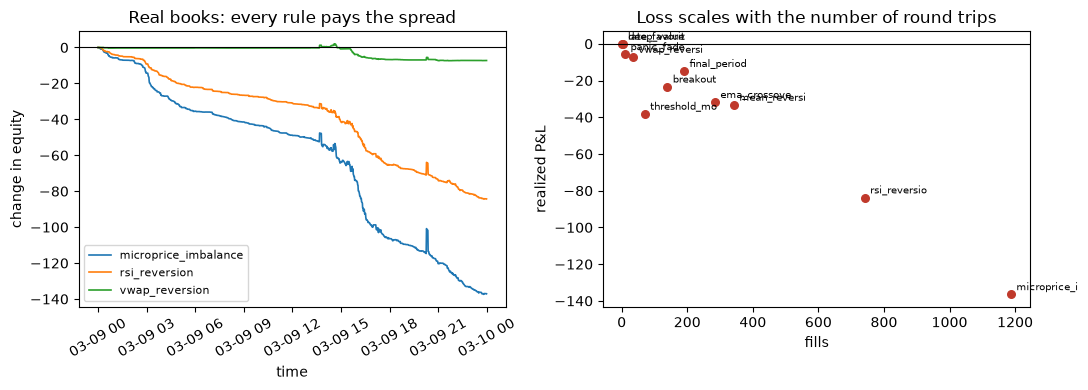

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name in ("microprice_imbalance", "rsi_reversion", best_name):
    if name not in results:
        continue
    curve = results[name].equity.to_pandas().sort_values("ts")
    axes[0].plot(curve.ts, curve.equity - curve.equity.iloc[0], lw=1.2, label=name)
axes[0].axhline(0.0, color="black", lw=0.8)
axes[0].set_title("Real books: every rule pays the spread")
axes[0].set_xlabel("time")
axes[0].set_ylabel("change in equity")
axes[0].tick_params(axis="x", labelrotation=30)
axes[0].legend(fontsize=8)
axes[1].scatter(traded.fills, traded.realized_pnl, s=30, color="#c0392b")
for row in traded.itertuples():
    axes[1].annotate(row.strategy[:12], (row.fills, row.realized_pnl),
                     textcoords="offset points", xytext=(4, 3), fontsize=7)
axes[1].axhline(0.0, color="black", lw=0.8)
axes[1].set_title("Loss scales with the number of round trips")
axes[1].set_xlabel("fills")
axes[1].set_ylabel("realized P&L")
fig.tight_layout()

## Reproduce it

The one claim that has to hold whatever the result is. `verify()` re-executes
the stored config against the same pin and compares every result table row for
row, so a negative finding is as reproducible as a positive one would be.

In [18]:
verified = results[best_name].verify()
print(f"verified: {verified['verified']}")
print(f"tables compared: {list(verified['tables_equal'])}")
print(f"data pin: {results[best_name].config.data.snapshot}")
print(f"trial digest: {results[best_name].config.trial_digest[:16]}")

verified: True
tables compared: ['bt_orders', 'bt_fills', 'bt_positions', 'bt_equity']
data pin: real-v1
trial digest: 3771d276adab30ab


## Takeaways

- On real Polymarket books, all eleven stock rules lose after costs, and the
  loss correlates with trade count. Cheap rules lose slowly; the busiest rule
  lost the most. Treat any backtest that shows otherwise on one day of six
  markets as a cost model that is missing something.
- The cost budget and the loss agree to a few percent, so the implied gross
  edge is about zero. These rules did not have an edge that costs ate; they had
  no edge and paid the costs. That is a sharper diagnosis than "too expensive"
  and the arithmetic supports it.
- Zero out the fee and the rule still loses, which localises what remains to the
  spread. Worth separating: a fee is negotiable at volume, a spread is not.
- The capture's limits are the study's limits. One day means nothing settles,
  YES-only means no parity trade, and full depth means an explicit, reported
  truncation to top of book. All three are properties of the data, and all
  three are visible in the result rather than buried.
- A negative result still needs the honest machinery. Eleven rules tried is a
  search, so the winner's Sharpe was deflated against eleven trials and did not
  clear the bar.
- h5i-db features doing the work: an `ArchiveLayout` literal reading a
  JSON-payload capture with no new code, reported depth truncation instead of a
  silent cap, one pinned snapshot behind eleven runs, the observability gate
  refusing to settle what the replay never reached, and `verify()` making the
  negative finding reproducible.

In [19]:
db.close()